## Configuration and Loading the Model

In [1]:
# Is the model EfficientNet?
eff_net = True
model_path = '/kaggle/input/models/tatumsoward/galaxymorphology-efficientnetv1/pytorch/default/1/efficientnet_b0_v1.pth'

import torch
import torchvision.models as models

# 2. Initialize the architecture (ensure it matches the version used for training)
if eff_net:
    model = models.efficientnet_b0()
    model.classifier[1] = torch.nn.Linear(in_features=1280, out_features=3)

else:
    model = model.resnet18()
    model.fc = torch.nn.Linear(in_features=model.fc.in_features, out_features=3)

# 3. Load the state_dict (weights) from the file
# Use map_location='cpu' if you are not using a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

state_dict = torch.load(model_path, map_location=device)

# 4. Apply the weights to your model architecture
model.load_state_dict(state_dict)

# 5. Now you can set it to evaluation mode
model.eval()

print("Model loaded successfully!")


Using device: cuda
Model loaded successfully!


## Loading the Test Set

In [2]:
import pandas as pd
import os

# 1. Get the Labels from your Preprocessing output
# (Just unzip the SMALL output.zip for the CSVs)
!unzip -q /kaggle/input/notebooks/tatumsoward/aig210-galaxyzoopreprocessing/_output_.zip -d /kaggle/temp/

# 2. Path to your pre-split CSV
TRAIN_CSV = '/kaggle/temp/train_split.csv'

# 3. Path to the ORIGINAL images (Mount the dataset for this!)
# Change this path to the exact location of the dataset ZIP
IMG_ZIP = '/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge/images_training_rev1.zip'

# 4. Unzip the images ONLY to the fast temp directory
!unzip -q {IMG_ZIP} -d /kaggle/temp/images/

BASE_PATH = '/kaggle/temp/'
IMG_DIR = os.path.join(BASE_PATH, 'images_training_rev1', 'images_training_rev1')

print("CSVs and Images are now linked and ready in /kaggle/temp/")

CSVs and Images are now linked and ready in /kaggle/temp/


In [3]:
import json

# 1. Load the stats from the same temp directory as your CSVs
stats_path = '/kaggle/temp/norm_stats.json'

with open(stats_path, 'r') as f:
    norm_dict = json.load(f)

GALAXY_MEAN = norm_dict['mean']
GALAXY_STD = norm_dict['std']

print(f"✅ Loaded Normalization Stats:")
print(f"Mean: {GALAXY_MEAN}")
print(f"Std:  {GALAXY_STD}")

✅ Loaded Normalization Stats:
Mean: [0.0462644841195366, 0.04110195352379381, 0.030947859142717995]
Std:  [0.0896679521649469, 0.0753237875670829, 0.0674412436919027]


In [4]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)), #for EfficiNet
    #transforms.CenterCrop(CFG['img_size']), # for ResNet
    transforms.RandomRotation(180), # Galaxies can be at any angle!
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), #for EfficiNet
    transforms.ToTensor(),
    transforms.Normalize(mean=GALAXY_MEAN, std=GALAXY_STD)
])

val_transforms = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=GALAXY_MEAN, std=GALAXY_STD)
])

In [5]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image

# Update your paths to point to the TEMP directory
BASE_PATH = '/kaggle/temp/'
TRAIN_CSV = os.path.join(BASE_PATH, 'train_split.csv')
# Note: Unzipping 'images_training_rev1.zip' usually creates a subfolder with the same name
IMG_DIR = os.path.join(BASE_PATH, 'images_training_rev1', 'images_training_rev1')

class GalaxyDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        # Read and force a clean integer index
        self.df = pd.read_csv(csv_file).reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        # Ensure keys match exactly what is in your CSV
        self.label_map = {'Elliptical': 0, 'Spiral': 1, 'Irregular': 2}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # FORCE idx to be a Python int. 
        # Sometimes Samplers pass a numpy.int64 which can cause indexing bugs.
        if hasattr(idx, 'item'):
            idx = idx.item()
        idx = int(idx)

        row = self.df.iloc[idx]
        
        # 1. Handle Label (The most likely source of 'string index' errors)
        label_name = str(row['label']) 
        label = self.label_map[label_name]
        
        # 2. Handle Image ID
        img_id = str(int(row['GalaxyID']))
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [6]:
from torch.utils.data import DataLoader

# 1. Create the Test Dataset Instance
# Use the same transforms as your validation set (no augmentation)
test_dataset = GalaxyDataset(
    csv_file=os.path.join(BASE_PATH, 'test_split.csv'), 
    img_dir=IMG_DIR, 
    transform=val_transforms
)

# 2. Create the Test Loader
test_loader = DataLoader(
    test_dataset, 
    batch_size=8, 
    shuffle=False, # Crucial: Keep order for the confusion matrix
    num_workers=0,
    pin_memory=False
)

print(f"✅ Test Loader Ready with {len(test_dataset)} images.")

✅ Test Loader Ready with 2053 images.


## Grad-CAM

In [7]:
import numpy as np
import cv2
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.hooks = [
            target_layer.register_forward_hook(self.save_activation),
            target_layer.register_full_backward_hook(self.save_gradient)
        ]

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
        
        # Backward pass for the specific class
        loss = output[0, class_idx]
        loss.backward()

        # Weight the filters by the gradients (Global Average Pooling)
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        # Weighted sum of feature maps
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # ReLU to keep only features that have a positive influence on the class
        cam = np.maximum(cam.detach().cpu().numpy(), 0)
        
        # Normalize and Resize
        cam = cv2.resize(cam, (input_tensor.shape[2], input_tensor.shape[3]))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def __del__(self):
        for hook in self.hooks:
            hook.remove()

In [8]:
def apply_colormap_on_image(org_img, heatmap):
    # Convert heatmap to RGB colormap
    heatmap_img = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_img = cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB)
    
    # Superimpose
    result = heatmap_img * 0.4 + org_img * 0.6
    return np.uint8(result)

In [9]:
# In torchvision EfficientNet, features are in a Sequential block
if eff_net:
    target_layer = model.features[-1] 
    cam_extractor = GradCAM(model, target_layer)

# Assuming 'model' is your ResNet18
else:
    target_layer = model.layer4[-1] 
    cam_extractor = GradCAM(model, target_layer)

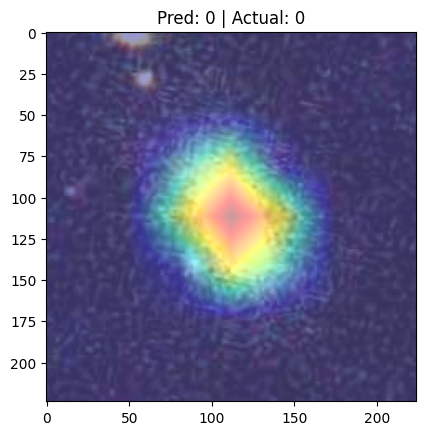

In [10]:
model.eval()
input_image, label = next(iter(test_loader))
input_tensor = input_image[0].unsqueeze(0).to(device)

# Generate Heatmap
heatmap, pred_idx = cam_extractor.generate_heatmap(input_tensor)

# Prepare original image for display (Undo normalization)
img_np = input_image[0].permute(1, 2, 0).cpu().numpy()
img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
img_np = np.clip(img_np, 0, 1) * 255

# Visualize
final_viz = apply_colormap_on_image(img_np, heatmap)
plt.imshow(final_viz)
plt.title(f"Pred: {pred_idx} | Actual: {label[0].item()}")
plt.show()